In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка отображения графиков
%matplotlib inline

In [2]:
df = pd.read_csv('../data/train.csv')

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [8]:
df.shape

(891, 12)

In [3]:
# Точный подсчет пропусков
missing_values = df.isnull().sum()
missing_percent = 100 * missing_values / len(df)
missing_table = pd.concat([missing_values, missing_percent], axis=1, keys=['Total', 'Percent'])
print(missing_table)

             Total    Percent
PassengerId      0   0.000000
Survived         0   0.000000
Pclass           0   0.000000
Name             0   0.000000
Sex              0   0.000000
Age            177  19.865320
SibSp            0   0.000000
Parch            0   0.000000
Ticket           0   0.000000
Fare             0   0.000000
Cabin          687  77.104377
Embarked         2   0.224467


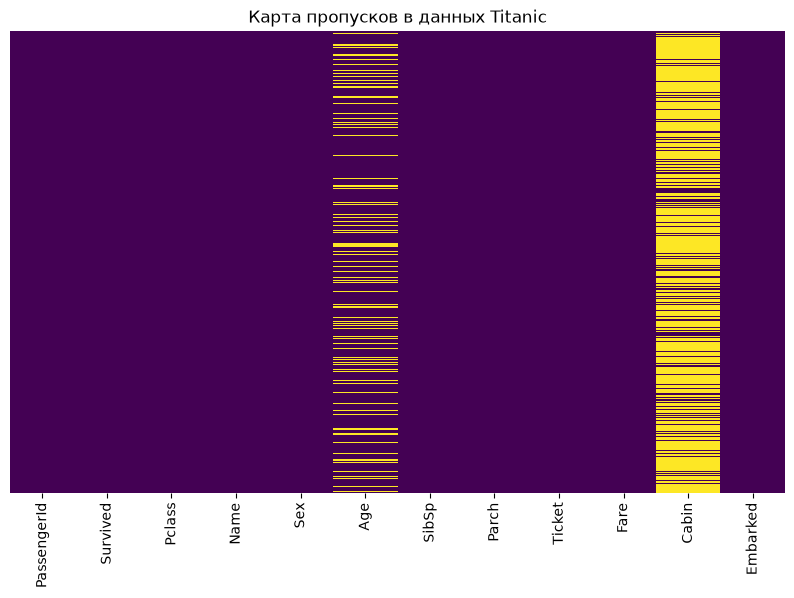

In [4]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Карта пропусков в данных Titanic')
plt.show()

In [ ]:
Решение EDA:
Age (Возраст): 177 пропусков. Заполним медианой. Медиана у нас = 28 лет.
Cabin (Каюта): 687 пропусков. Нет смысла заполнять. Создадим новый признак Has_Cabin (1 если каюта есть, 0 если нет), а старый столбец удалим.
Embarked (Порт посадки): 2 пропуска. Заполним модой (самым частым значением). 
    Из вывода describe мы видим, что top = 'S', freq = 644. Значит, заполняем буквой 'S'.

=== Выживаемость по полу ===
Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815

=== Выживаемость по классу ===
Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.763747  24.236253

=== Выживаемость по порту ===
Survived          0          1
Embarked                      
C         44.642857  55.357143
Q         61.038961  38.961039
S         66.304348  33.695652


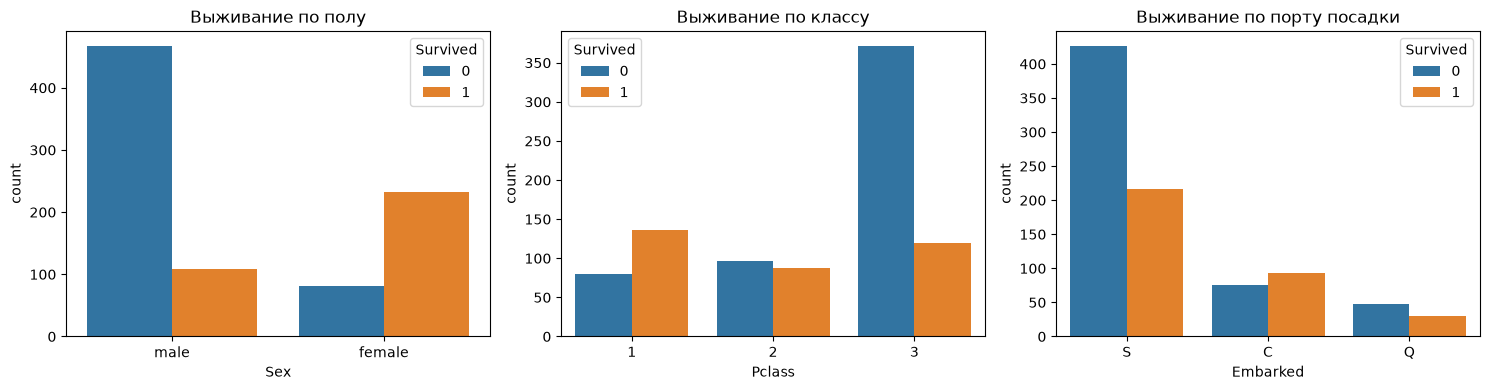

In [5]:
# 1. Влияние пола
print("=== Выживаемость по полу ===")
print(pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100)

# 2. Влияние класса
print("\n=== Выживаемость по классу ===")
print(pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100)

# 3. Влияние порта посадки
print("\n=== Выживаемость по порту ===")
print(pd.crosstab(df['Embarked'], df['Survived'], normalize='index') * 100)

# 4. Визуализация (графики)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0])
axes[0].set_title('Выживание по полу')

sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[1])
axes[1].set_title('Выживание по классу')

sns.countplot(x='Embarked', hue='Survived', data=df, ax=axes[2])
axes[2].set_title('Выживание по порту посадки')

plt.tight_layout()
plt.show()

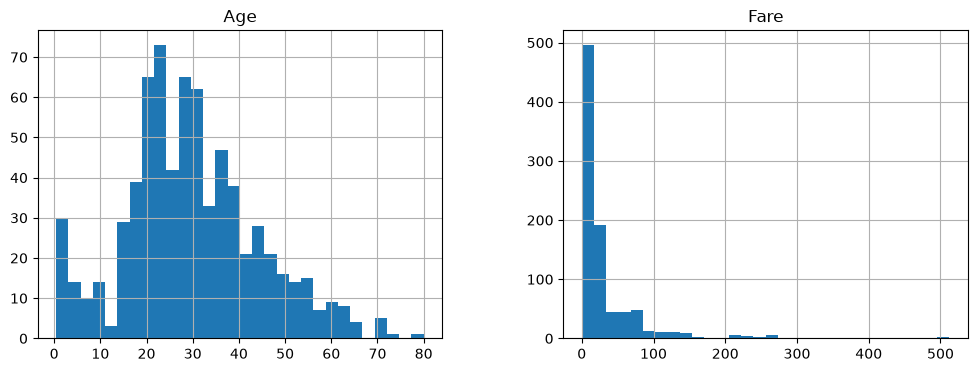

In [6]:
df[['Age', 'Fare']].hist(bins=30, figsize=(12, 4))
plt.show()

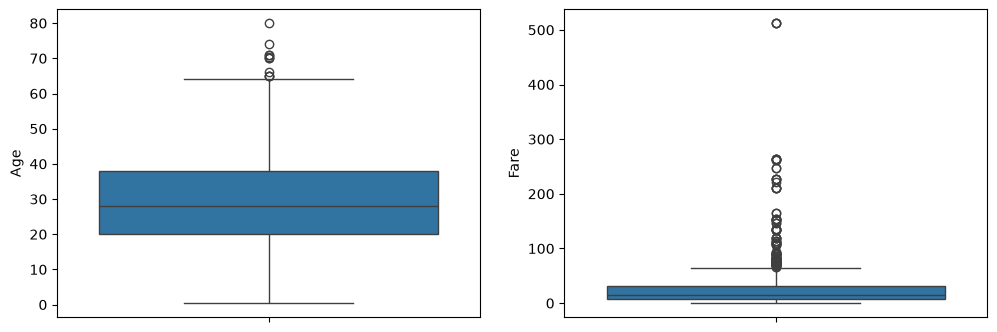

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df['Age'], ax=axes[0])
sns.boxplot(y=df['Fare'], ax=axes[1])
plt.show()

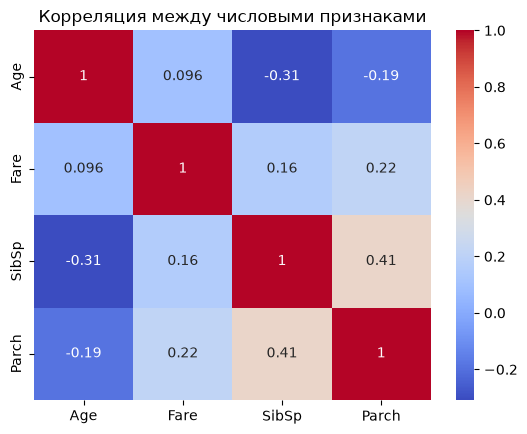

In [8]:
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Корреляция между числовыми признаками')
plt.show()

In [12]:
# Или вот корреляция в матрице
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

            Age      Fare     SibSp     Parch
Age    1.000000  0.096067 -0.308247 -0.189119
Fare   0.096067  1.000000  0.159651  0.216225
SibSp -0.308247  0.159651  1.000000  0.414838
Parch -0.189119  0.216225  0.414838  1.000000


In [ ]:
Вывод №1: Семейные признаки (SibSp и Parch) тесно связаны
Коэффициент: 0.4148 (умеренная положительная корреляция).
    
Что это значит:
Пассажиры, у которых на борту были братья/сёстры или супруги (SibSp), с высокой вероятностью также везли родителей или детей (Parch). 
Это логично — люди путешествовали семьями.
Эти два признака дублируют информацию. Их нужно объединить в один, например:
    FamilySize = SibSp + Parch + 1 (общий размер семьи).

Или сделать бинарный признак IsAlone = 1, если FamilySize == 1.
Это снизит мультиколлинеарность и упростит модель.

In [ ]:
Вывод №2: Возраст обратно связан с наличием семьи
Коэффициенты:
Age vs SibSp = -0.308
Age vs Parch = -0.189

Что это значит:
Чем старше пассажир, тем меньше у него на борту братьев/сестёр/супругов и детей. 
    И наоборот — дети и молодые люди часто путешествовали с родителями или сиблингами. 
    Отрицательная связь говорит о том, что молодые пассажиры "тянут" семейные признаки вверх.


Возможно, имеет смысл создать отдельный признак Child (ребёнок до 12 лет), 
так как на Титанике дети выживали чаще, и этот признак будет пересекаться с Parch (дети ехали с родителями).

In [ ]:
Вывод №3: Стоимость билета (Fare) связана с размером семьи
Коэффициенты:
Fare vs SibSp = 0.159
Fare vs Parch = 0.216

Что это значит:
Семьи (особенно с детьми) покупали более дорогие билеты или несколько билетов одновременно, 
что увеличивало общую стоимость (Fare). Также, возможно, в первом классе было больше семейных пар.

Fare косвенно "впитывает" в себя информацию о семье. 
После добавления FamilySize важность Fare немного упадет.

In [9]:
df[numeric_cols + ['Survived']].corr()['Survived'].sort_values(ascending=False)

Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.077221
Name: Survived, dtype: float64

In [10]:
df['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

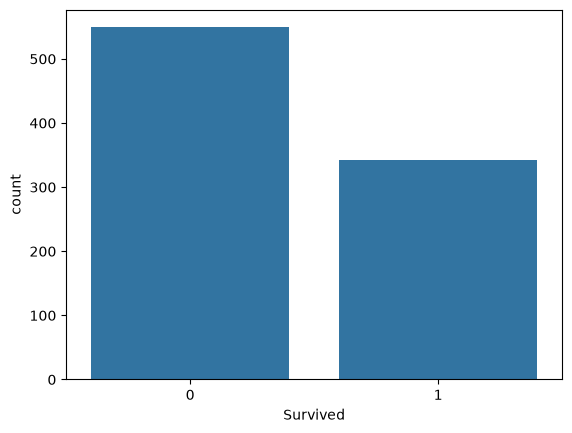

In [11]:
sns.countplot(x='Survived', data=df)
plt.show()